## Lab Overview: Exploratory Data Analysis

Before building a machine learning model, we first need to understand the data. This process is called **Exploratory Data Analysis (EDA)**. EDA uses statistics and visualization to help us understand the structure and behavior of a dataset before selecting or applying a modeling approach.

In this lab, EDA serves several important purposes:

| Function | Description |
|---|---|
| **Characterize distributions** | Understand central tendency, variability, skewness, and outliers |
| **Measure relationships** | Identify and quantify associations among variables and between variables and outcomes |
| **Identify patterns** | Distinguish expected behavior from unusual observations, trends, and clusters |
| **Communicate insights** | Make findings understandable through quantitative evidence and visual representations |

These activities help us answer crucial questions before modeling, such as:

- What does typical traffic look like?
- How much do the features vary?
- Are some features highly correlated?
- Do the features appear to contain useful signals for distinguishing malicious from benign traffic?

In the remainder of this section, we will use EDA to progressively characterize the a cyber data, measure relationships among features, and identify patterns that may be useful for detecting malicious activity.

## DNS Data Exfiltration Challenge Problem Overview

In this lab, your objective is to perform an EDA of DNS traffic contained in the **CIC-Bell-DNS-EXF-2021** dataset. Developed in collaboration with Bell Canada Cyber Threat Intelligence (CTI), this dataset focuses specifically on identifying DNS-based data exfiltration and covert command-and-control (C2) tunneling—common techniques used by adversaries to stealthily extract sensitive information from enterprise networks. Because DNS is an essential service, it is typically allowed through firewalls, making it an attractive channel for cybercriminals to encode and exfiltrate data without raising alarms.

For more details on the dataset, visit: [https://www.unb.ca/cic/datasets/dns-exf-2021.html](https://www.unb.ca/cic/datasets/dns-exf-2021.html)

## 1. Setup and Data Loading

In [3]:
import pandas as pd

# Handle Colab environment
colab = True
if colab:
    file_path = "https://raw.githubusercontent.com/mmw188/ISW_2026/main/data/Exfil_Data.csv"
else:
    file_path = './data/Exfil_Data.csv'

# Load data
data = pd.read_csv(file_path)

First, let's examine the general characteristics of the dataset, including the available features and the distribution of the target classes.

In [4]:
## View general features of data
print('Feature Names')
print(data.columns)
print('-' * 100)

print('Data Shape...')
print(data.shape)
print('-' * 100)

print('Class Labels...')
print(data['label'].value_counts())
print('-' * 100)

Feature Names
Index(['FQDN_count', 'subdomain_length', 'upper', 'lower', 'numeric',
       'entropy', 'special', 'labels', 'labels_max', 'labels_average',
       'longest_word', 'sld', 'len', 'subdomain', 'label'],
      dtype='object')
----------------------------------------------------------------------------------------------------
Data Shape...
(575146, 15)
----------------------------------------------------------------------------------------------------
Class Labels...
label
attack    294003
benign    281143
Name: count, dtype: int64
----------------------------------------------------------------------------------------------------


### Feature Definitions

The data consist of the following features:

| Feature | Data Type | Description |
|---|---|---|
| `FQDN_count` | Integer | Total number of characters in the fully qualified domain name (FQDN). |
| `subdomain_length` | Integer | Number of characters in the subdomain. |
| `upper` | Integer | Number of uppercase characters. |
| `lower` | Integer | Number of lowercase characters. |
| `numeric` | Integer | Number of numeric characters. |
| `entropy` | Float | Shannon entropy of the query name, measuring randomness/diversity. |
| `special` | Integer | Number of special characters (e.g., `-`, `_`, `=`, spaces). |
| `labels` | Integer | Number of labels in the domain name (separated by periods). |
| `labels_max` | Integer | Maximum length of any individual domain label. |
| `labels_average` | Float | Average length of the domain labels. |
| `longest_word` | Float | Ratio of the longest meaningful word to the total domain length. |
| `sld` | String | Second-level domain (SLD). |
| `len` | Integer | Total length of the domain and subdomain. |
| `subdomain` | Boolean | Indicates whether the domain contains a subdomain. |
| `label` | String | Target class/label (`attack` or `benign`). |


### Outcome Definitions

The data contain two classes of outputs.

| Class Label | Description |
|---|---|
| `attack` | DNS queries associated with data exfiltration activity. |
| `benign` | Legitimate DNS queries not associated with data exfiltration activity. |

## 2. Exploratory Data Analysis

### 2.1. Characterize Distributions

Before moving into modeling, it is important to understand the fundamental properties of our features. EDA helps us understand how values are distributed, identify unusual observations, and determine whether the data are consistent with the assumptions of potential modeling approaches.

#### 2.1.1. Visualizing Distributions

Visualization provides an intuitive way to understand the structure of our data. Different visualizations are appropriate for different types of variables and questions. The table below describes techniques for visualizing the distribution of a single feature.

| Visualization | Applicable Features | What It Helps Identify |
|---|---|---|
| **Histogram** | Continuous or discrete numerical | Distribution shape, central tendency, spread, skewness, and potential outliers |
| **Box plot** | Numerical | Median, quartiles, dispersion, and potential outliers | Useful for comparing distributions across groups |
| **Density / KDE plot** | Continuous numerical | Smoothed distribution shape, peaks, and differences in density |
| **Bar chart** | Categorical or discrete | Frequency or proportion of categories |
| **Violin plot** | Continuous numerical | Distribution shape, density, central tendency, and dispersion |
| **ECDF plot** | Numerical | Cumulative distribution, percentiles, and differences in distributions |

In this section, we will use histograms to visualize features.

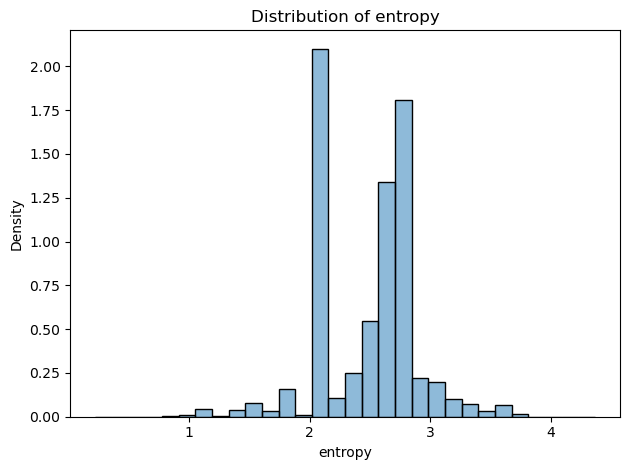

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select the feature to visualize
feature = "entropy"

sns.histplot(
    data[feature],
    bins=30,
    stat="density",
    alpha=0.5,
)

plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Density")

plt.tight_layout()
plt.show()

#### 2.1.2. Quantifying Central Tendency and Dispersion

In addition to visualizing data, it is important to quantify the fundamental properties of our features. We analyze **central tendency** and **dispersion** to understand what is typical in the data and how much observations vary.

**Central Tendency**

- **Mean ($\mu$):** The arithmetic average of the values.

  $$\mu = \frac{1}{n} \sum_{i=1}^{n} x_i$$

- **Median:** The middle value of a data set when ordered from least to greatest. It is more robust to outliers than the mean.

**Dispersion (Spread)**

- **Standard Deviation ($\sigma$):** A measure of how much the values deviate from the mean.

  $$\sigma = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2}$$

- **Variance ($\sigma^2$):** The squared standard deviation and a measure of the overall variability in the data.

  $$\sigma^2 = \frac{1}{n} \sum_{i=1}^{n} (x_i - \mu)^2$$

- **Interquartile Range (IQR):** The range containing the middle 50% of observations.

  $$IQR = Q_3 - Q_1$$

- **Coefficient of Variation (CV):** A normalized measure of variability relative to the mean.

  $$CV = \frac{\sigma}{\mu}$$

The coefficient of variation is particularly useful when comparing variability across features with different scales. For example, in network traffic analysis, **inter-arrival time CV** can quantify the regularity of communication: lower values indicate that observations tend to occur at more consistent intervals.

Together, visualization and statistics provide complementary perspectives:

> **Visualization helps us see patterns; statistics help us quantify them.**

In this section, we will use mean, median, and standard deviation to quantify properties of a feature's distribution.

In [4]:
# Select the feature to analyze
feature = "entropy"

mean = data[feature].mean()
median = data[feature].median()
std = data[feature].std()

print(f"--- {feature} ---")
print(f"Central tendency")
print(f"  Mean:   {mean:.4f}")
print(f"  Median: {median:.4f}")
print()
print(f"Dispersion")
print(f"  Std:    {std:.4f}")

--- entropy ---
Central tendency
  Mean:   2.4639
  Median: 2.5704

Dispersion
  Std:    0.4135


We can use statistics and visualizations together. In this section, we will use histograms to visualize distribution shape, while using descriptive statistics to quantify central tendency.

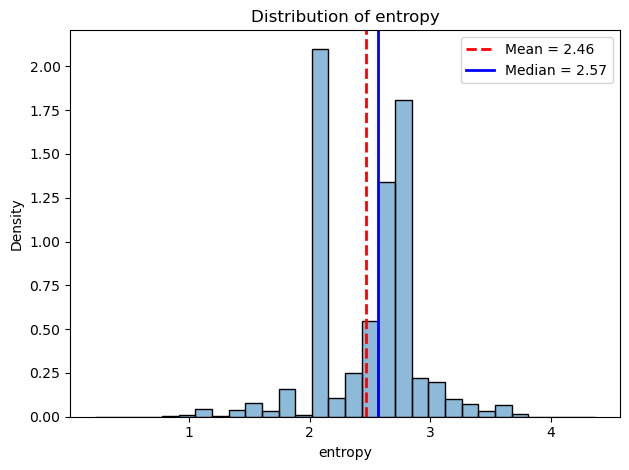

In [6]:
sns.histplot(
    data[feature],
    bins=30,
    stat="density",
    alpha=0.5,
)

plt.axvline(
    mean,
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean = {mean:.2f}",
)

plt.axvline(
    median,
    color="blue",
    linestyle="-",
    linewidth=2,
    label=f"Median = {median:.2f}",
)

plt.title(f"Distribution of {feature}")
plt.xlabel(feature)
plt.ylabel("Density")
plt.legend()

plt.tight_layout()
plt.show()

#### 2.1.3. Assignment

Now that we have introduced visualization and descriptive statistics, apply these techniques to explore the distributions of different features in the dataset.

1. **Try different visualization techniques.**  
   Use the visualization table above as a guide and experiment with different plot types. Consult the documentation as needed: [Matplotlib documentation](https://matplotlib.org/stable/plot_types/index.html)

2. **Try different features.**  
   Change the `feature` variable to examine several numerical features in the dataset.

3. **Quantify the distributions.**  
   For each feature, calculate the **mean, median, and standard deviation**. Consider also calculating additional measures such as the IQR and coefficient of variation.

4. **Compare statistics with visualizations.**  
   Create a histogram with the mean and median displayed on the plot. Compare the numerical statistics with what you observe visually.

5. **Interpret the distributions.**  
   As you explore different features, consider:
   - Does the feature appear to have a single group or distinct groups?
   - Is the distribution approximately symmetric or skewed?
   - Does the feature has relatively high or low variability?
   - Are there potential outliers?
   - Notice how different visualization techniques reveal different aspects of the same distribution.

### 2.2. Measure relationships

In addition to understanding individual feature distributions, it is important to examine how features relate to one another. Relationships between features can reveal patterns that may not be apparent when examining variables independently and can help identify redundant or strongly associated features.

#### 2.2.1. Visualizing Associations

After examining the distributions of individual features, we can begin examining how features relate to one another. Visualizing associations helps us identify patterns that may not be apparent when looking at each feature independently. The table below describes techniques for visualizing associations between two features.


| Visualization | Applicable Features | What It Helps Identify |
|---|---|---|
| **Scatter plot** | Two numerical features | Trends, relationships, clusters, nonlinear patterns, and anomalies |
| **Scatter plot with trend line** | Two numerical features | Direction and approximate strength of a relationship |
| **Pair plot** | Multiple numerical features | Relationships, distributions, clusters, and potential feature redundancy |
| **Correlation heatmap** | Multiple numerical features | Strength and direction of pairwise correlations |

In this section, we will use scatter plots to visualize associations between features.

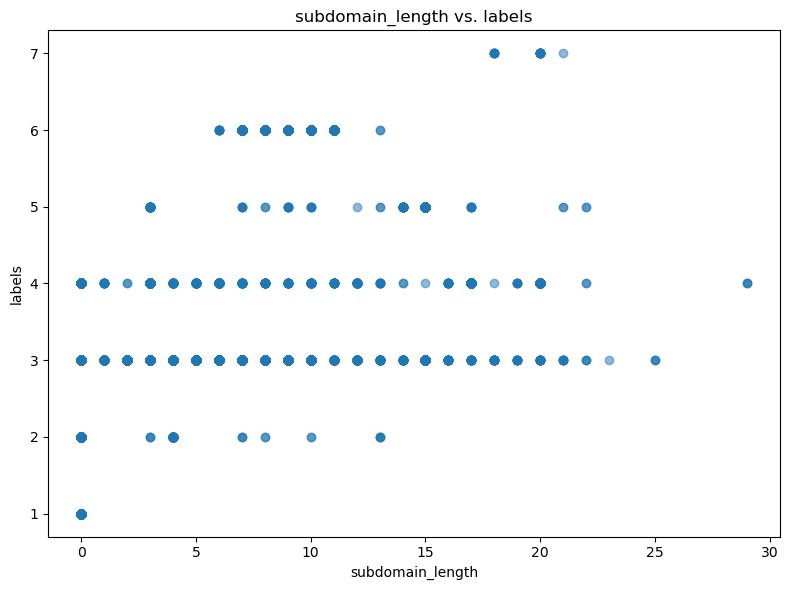

In [7]:
# Select two numerical features to compare
x_feature = "subdomain_length" # TODO: try a different feature
y_feature = "labels"           # TODO: try a different feature

plt.figure(figsize=(8, 6))

plt.scatter(
    data[x_feature],
    data[y_feature],
    alpha=0.5,
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.title(f"{x_feature} vs. {y_feature}")

plt.tight_layout()
plt.show()

#### 2.2.2. Quantifying Associations

In addition to visualizing data, we can also use **quantitative measures** to describe the strength and direction of those relationships. Correlation provides a numerical summary of the association between two variables.

**Pearson Correlation Coefficient ($r$)** measures the strength and direction of a **linear relationship** between two numerical variables. The value of $r$ ranges from -1 to 1:

- $r = 1$: Perfect positive linear relationship.
- $r = 0$: No linear relationship.
- $r = -1$: Perfect negative linear relationship.

Values between these extremes indicate varying degrees of linear association. The closer the absolute value of $r$ is to 1, the stronger the linear relationship. The sign indicates the direction of the relationship.

The formula for $r$ is:

$$
r = \frac{\sum_{i=1}^{n} (x_i - \bar{x})(y_i - \bar{y})}
{\sqrt{\sum_{i=1}^{n} (x_i - \bar{x})^2
\sum_{i=1}^{n} (y_i - \bar{y})^2}}
$$

Correlation can help us identify features that may contain similar information or that are strongly associated with one another. However, correlation should be interpreted carefully. **Pearson correlation measures linear relationships**, so a correlation near zero does not necessarily mean that two variables are unrelated. A strong nonlinear relationship, for example, may have a relatively small Pearson correlation.

Correlation also does not imply causation. A strong correlation indicates that two variables are associated, but it does not tell us that changes in one variable cause changes in the other.

> **Visualization helps us see relationships; correlation helps us quantify them.**

In this section, we will calculate correlations between individual feature pairs to identify relationships across all numerical features. We will then compare these quantitative measures with the patterns observed in our scatter plots.

In [8]:
# Select the features to analyze

correlation = data[x_feature].corr(data[y_feature])

print(
    f"Pearson correlation between "
    f"{x_feature} and {y_feature}: {correlation:.4f}"
)

Pearson correlation between subdomain_length and labels: 0.9233


We can use statistics and visualizations together to better understand relationships between features. In this section, we will use scatter plots to visually examine associations between pairs of numerical features, while using correlation coefficients to quantify the strength and direction of those relationships.

Using both approaches provides a more complete picture: visualizations help us see the relationship; correlation helps us quantify it.

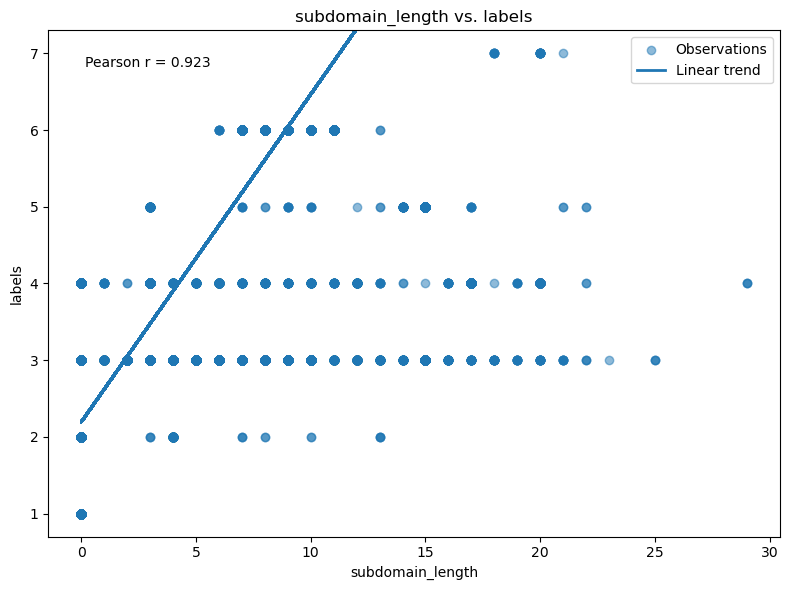

In [9]:
import numpy as np

# Remove missing values for plotting and trend-line calculation
plot_data = data[[x_feature, y_feature]].dropna()

x = plot_data[x_feature]
y = plot_data[y_feature]

# Calculate linear trend line
slope, intercept = np.polyfit(x, y, 1)
trend_line = slope * x + intercept

# Create scatter plot
plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    alpha=0.5,
    label="Observations",
)

# Add trend line
plt.plot(
    x,
    trend_line,
    linewidth=2,
    label="Linear trend",
)

plt.xlabel(x_feature)
plt.ylabel(y_feature)
plt.title(f"{x_feature} vs. {y_feature}")

# Set axis limits based on feature ranges
x_range = x.max() - x.min()
y_range = y.max() - y.min()

plt.xlim(
    x.min() - 0.05 * x_range,
    x.max() + 0.05 * x_range,
)

plt.ylim(
    y.min() - 0.05 * y_range,
    y.max() + 0.05 * y_range,
)

# Display correlation on the plot
plt.text(
    0.05,
    0.95,
    f"Pearson r = {correlation:.3f}",
    transform=plt.gca().transAxes,
    verticalalignment="top",
)

plt.legend()
plt.tight_layout()
plt.show()

#### 2.2.3. Assignment

Now that we have introduced visualization and correlation, apply these techniques to explore the relationships among different numerical features in the dataset.

1. **Try different feature pairs.**  
   Change the `x_feature` and `y_feature` variables to examine relationships between several pairs of numerical features.

2. **Visualize the relationships.**  
   Create scatter plots for your selected feature pairs. Look for:
   - Positive or negative relationships
   - Linear or nonlinear patterns
   - Clusters or groups of observations
   - Potential outliers or unusual observations

3. **Quantify the relationships.**  
   For each feature pair, calculate the **Pearson correlation coefficient**. Consider the strength and direction of each correlation.

4. **Compare statistics with visualizations.**  
   Compare the correlation coefficient with the pattern you observe in the scatter plot. Consider:
   - Does a strong correlation correspond to a clear visual relationship?
   - Does a weak correlation appear to indicate little or no relationship?
   - Are there cases where the visualization reveals patterns that the correlation coefficient does not capture?

5. **Interpret the relationships.**  
   As you explore different feature pairs, consider:
   - Which features are most strongly associated?
   - Does the relationship appear linear?
   - Are there clusters or outliers that may influence the correlation?
   - Can two features have a weak Pearson correlation but still have a meaningful nonlinear relationship?
   - Are there features that appear to contain redundant information?

The goal is to understand that **correlation provides a numerical summary of a relationship, while visualization provides context for interpreting that summary**.

> **Don't just find strong correlations—look at the data and determine whether the relationships make sense.**

### 2.3. Identify Patterns and Anomalies

After characterizing individual feature distributions and measuring relationships among features, we can begin looking for **patterns and anomalies** in the data. In the context of attack detection, this means examining whether the behavior of features differs between the **benign** and **attack** classes.

Patterns may appear as differences in central tendency, variability, distribution shape, or the presence of unusual observations. Identifying these differences can help us determine whether individual features contain signals that may be useful for distinguishing benign from malicious activity.

We can use **visualizations and statistics together** to identify these patterns and anomalies. In this section, we will compare feature distributions between the benign and attack classes and examine observations that differ substantially from the rest of the data.

#### 2.3.1. Visualizing Patterns and Anomalies

One useful approach for comparing distributions across classes is the **box plot**. Box plots provide a compact way to visualize the center and spread of a distribution while also highlighting potential outliers.

The **Interquartile Range (IQR)** represents the range containing the middle 50% of the data:

$$
IQR = Q_3 - Q_1
$$

where $Q_1$ is the first quartile (25th percentile) and $Q_3$ is the third quartile (75th percentile).

Box plots typically identify potential outliers as observations falling below

$$
Q_1 - 1.5 \times IQR
$$

or above

$$
Q_3 + 1.5 \times IQR.
$$

These observations are not necessarily errors or malicious activity. They simply represent values that are relatively unusual compared with the rest of the observations and should be investigated in context.

By comparing box plots for benign and attack traffic, we can look for differences in **central tendency, variability, distribution, and potential outliers**. These differences may provide useful signals for distinguishing between the two classes.

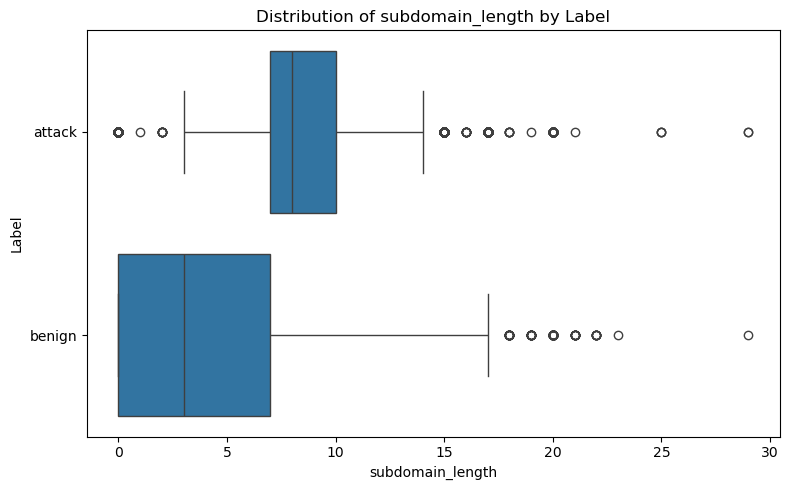

In [15]:
# Select the feature to compare
feature = "entropy"

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=data,
    x=feature,
    y="label",
)

plt.title(f"Distribution of {feature} by Label")
plt.xlabel(feature)
plt.ylabel("Label")

plt.tight_layout()
plt.show()

#### 2.3.2. Quantifying Differences

While visualization allows us to identify apparent differences between benign and attack traffic, we can also use **statistical hypothesis testing** to quantify whether those differences are statistically significant.

**Student's t-test** is used to test whether the means of two groups are statistically different from one another.

**Hypotheses:**

- **Null Hypothesis ($H_0$):** There is no difference in the population means of the two groups.

  $$
  \mu_{attack} = \mu_{benign}
  $$

- **Alternative Hypothesis ($H_a$):** The population means of the two groups are different.

  $$
  \mu_{attack} \neq \mu_{benign}
  $$

The test produces a **p-value**, which indicates how compatible the observed difference is with the null hypothesis. Using a significance level of $\alpha = 0.05$:

- If **$p < 0.05$**, we reject the null hypothesis and conclude that there is statistically significant evidence of a difference in the group means.
- If **$p \geq 0.05$**, we do not reject the null hypothesis because there is insufficient evidence to conclude that the group means differ.

Statistical significance does not necessarily mean that a difference is **large or practically important**. With a sufficiently large dataset, even small differences can be statistically significant. Therefore, hypothesis testing should be considered alongside **visualizations and measures of effect size** when evaluating whether a feature provides a useful signal for machine learning.

In this section, we will use Student's t-test to quantify differences between benign and attack traffic and compare the results with the patterns observed in our visualizations.

In [17]:
from scipy import stats

# Select the feature to test
feature = "entropy"

# Separate the two classes
attack_values = data[data["label"] == "attack"][feature]
benign_values = data[data["label"] == "benign"][feature]

# Perform Student's t-test
result = stats.ttest_ind(
    attack_values,
    benign_values,
    equal_var=True,
)

# Display the results
print(f"Student's t-test for: {feature}")
print(f"Attack mean:    {attack_values.mean():.4f}")
print(f"Benign mean:    {benign_values.mean():.4f}")
print(f"Test statistic: {result.statistic:.4f}")
print(f"P-value:        {result.pvalue:.4e}")

Student's t-test for: subdomain_length
Attack mean:    8.0914
Benign mean:    3.8126
Test statistic: 497.3815
P-value:        0.0000e+00


In [12]:
alpha = 0.05

if result.pvalue < alpha:
    print(f"\nResult: Reject H₀ (p < {alpha})")
    print("There is statistically significant evidence of a difference in the group means.")
else:
    print(f"\nResult: Fail to reject H₀ (p >= {alpha})")
    print("There is insufficient evidence of a difference in the group means.")


Result: Reject H₀ (p < 0.05)
There is statistically significant evidence of a difference in the group means.


#### 2.3.3. Assignment

Now that we have introduced methods for identifying and quantifying differences between benign and attack traffic, apply these techniques to other features in the dataset.

1. **Choose different features.**  
   Change the `feature` variable and investigate several numerical features.

2. **Visualize the differences.**  
   Create a box plot for each selected feature to compare the distributions of benign and attack traffic. Look for differences in:
   - Central tendency
   - Variability
   - Distribution
   - Potential outliers

3. **Quantify the differences.**  
   Perform Student's t-test for each selected feature. Record the test statistic and p-value, and determine whether the difference in means is statistically significant at $\alpha = 0.05$.

4. **Compare visualization and statistics.**  
   For each feature, consider:
   - Do the distributions appear different?
   - Are the group means substantially different?
   - Is the difference statistically significant?
   - Does the statistical result agree with what you observed in the box plot?

5. **Identify potential signals.**  
   Identify features where benign and attack traffic exhibit meaningful differences. Consider whether these differences could provide useful signals for distinguishing between the two classes.

Remember that **statistical significance does not necessarily imply practical significance**. With a large dataset, even a small difference between groups can be statistically significant. Use both the visualizations and statistical results to determine whether a feature appears to contain a meaningful signal.

> **Use visualization to see the difference, hypothesis testing to quantify the evidence, and your own reasoning to determine whether the difference is meaningful.**

### 2.4. Communicate Insights

EDA is not complete when we have created plots or calculated statistics. An important part of EDA is being able to **communicate what we learned from the data**.

Throughout this section, we have examined the distributions of individual features, relationships between features, and differences between benign and attack traffic. We now need to bring these observations together and explain what they tell us about the dataset.

Good data analysis should answer three questions:

1. **What did you observe?**
2. **What evidence supports your observation?**
3. **Why does the observation matter?**

### Assignment

Review the EDA you performed in Sections 2.1–2.3 and identify **2–3 important insights** about the dataset.

For each insight, describe:

- **What you observed:** What pattern, relationship, or difference did you find?
- **Evidence:** Which visualization or statistic supports your observation?
- **Why it matters:** Why might this observation be relevant to detecting DNS-based data exfiltration?
- **Modeling implications:** How might this observation influence the features or modeling approach you use later?